<a href="https://colab.research.google.com/github/Jain-Dixon/MACHINE-LEARNING-WORKS/blob/main/AI_ML_INTERNSHIP_DAY_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#UNSUPERVISED LEARNING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dt=pd.read_csv("/content/Mall_Customers.csv")

In [ ]:
dt

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


<Axes: >

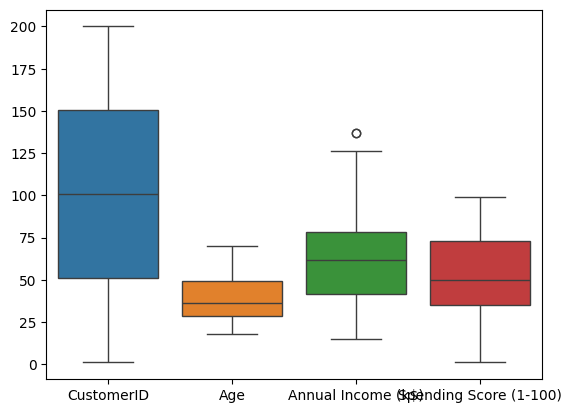

In [ ]:
sns.boxplot(dt)

In [ ]:
dt.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
dt.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
x = dt.drop(['CustomerID', 'Genre'], axis = 1)

In [ ]:
from sklearn.cluster import KMeans



In [ ]:
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

In [ ]:
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

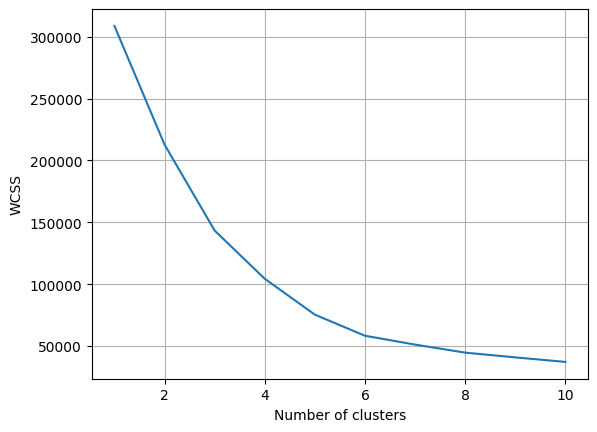

In [ ]:
plt.plot(range(1,11),wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
kmeans.fit(x)

KMeans(n_clusters=10, n_init=10, random_state=42)

In [ ]:
cluster_labels=kmeans.predict(x)

In [ ]:
cluster_labels

array([6, 3, 0, 3, 6, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 6, 3, 6, 3, 6, 3,
       0, 3, 0, 3, 6, 3, 6, 3, 0, 3, 0, 3, 0, 3, 0, 3, 6, 3, 9, 3, 6, 5,
       6, 3, 9, 5, 6, 6, 9, 5, 5, 9, 9, 6, 9, 9, 5, 9, 9, 5, 9, 9, 9, 5,
       2, 9, 5, 5, 9, 2, 9, 9, 9, 5, 2, 2, 5, 2, 9, 2, 9, 2, 5, 2, 9, 5,
       5, 2, 9, 5, 2, 2, 5, 5, 2, 5, 2, 5, 5, 2, 9, 5, 2, 5, 9, 2, 9, 9,
       9, 5, 2, 5, 5, 5, 9, 2, 2, 2, 5, 2, 2, 8, 7, 8, 2, 8, 7, 8, 7, 8,
       5, 8, 7, 8, 7, 8, 7, 8, 7, 8, 5, 8, 7, 8, 2, 8, 7, 8, 7, 8, 7, 8,
       7, 8, 7, 8, 7, 8, 2, 8, 7, 8, 7, 8, 7, 8, 7, 8, 7, 8, 7, 8, 7, 8,
       7, 8, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1], dtype=int32)

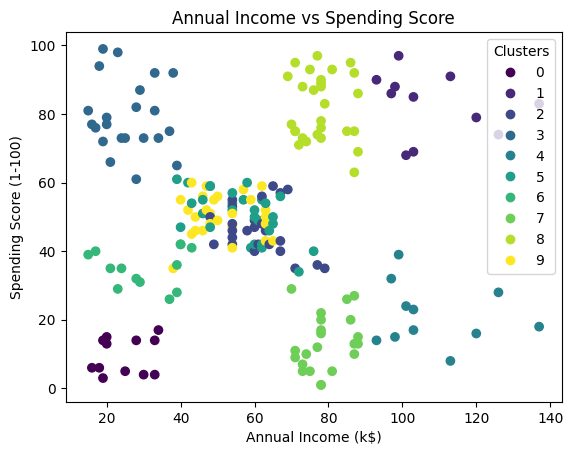

In [ ]:
scatter=plt.scatter(x['Annual Income (k$)'],x['Spending Score (1-100)'],c=cluster_labels)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(*scatter.legend_elements(),title='Clusters')
plt.title('Annual Income vs Spending Score')
plt.show()

In [ ]:
def predict_cluster(age,annual_income,spending_score):
  new_data = [[age,annual_income,spending_score]]
  cluster = kmeans.predict(new_data)
  return cluster[0]

In [ ]:
new_customer_income =50
new_customer_spending_score = 100
genre  = 'Male'
Genre = 1 if genre=='Male' else 0
age=25

In [ ]:
predicted_cluster = predict_cluster(age,new_customer_income,new_customer_spending_score)
print(f"The predicted cluster for the new customer is: {predicted_cluster}")

The predicted cluster for the new customer is: 3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
new_customer_income =50
new_customer_spending_score = 100
genre  = 'Male'
Genre = 1 if genre=='Male' else 0
age=25

In [ ]:
predicted_cluster = predict_cluster(age,new_customer_income,new_customer_spending_score)
print(f'The predicted cluster for the new customer is: {predicted_cluster}')

TypeError: predict_cluster() takes 3 positional arguments but 4 were given

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage,fcluster

In [ ]:
merging=linkage(x,method='ward')

In [ ]:
plt.figure(figsize=(10,6))
dendrogram(merging)
plt.axhline(340,color='green',linestyle='--')
plt.show()

In [ ]:
cluster_labels=fcluster(merging,340,criterion='distance')

In [ ]:
scatter=plt.scatter(x['Annual Income (k$)'],x['Spending Score (1-100)'],c=cluster_labels_hc)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(*scatter.legend_elements(),title='Clusters')
plt.title('Annual Income vs Spending Score')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
score_km=silhouette_score(x,cluster_labels)
score_hc=silhouette_score(x,cluster_labels_hc)
score_km

In [ ]:
score_hc

#ANN

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
data=pd.read_csv('/content/Social_Network_Ads.csv')

In [ ]:
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
data.drop('User ID',axis=1,inplace=True)

<Axes: >

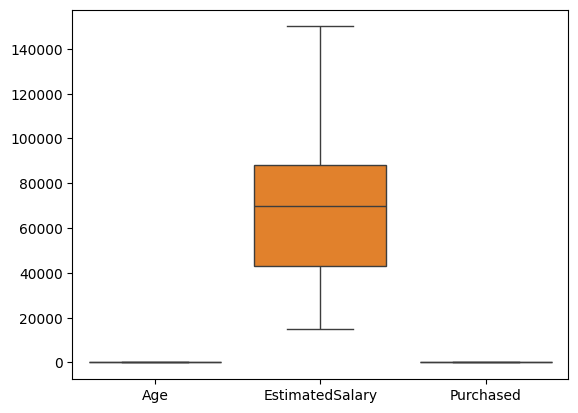

In [ ]:
sns.boxplot(data)

In [ ]:
data.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [ ]:
x=data[['Gender','Age','EstimatedSalary']]
y=data['Purchased']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()


In [ ]:
x_train[['Age','EstimatedSalary']]= sc.fit_transform (x_train[['Age','EstimatedSalary']])

In [ ]:

x_test[['Age','EstimatedSalary']]=sc.transform (x_test[['Age','EstimatedSalary']])

In [ ]:
x_train['Gender'] = x_train['Gender'].map({'Female': 0, 'Male': 1})
x_test['Gender'] = x_test['Gender'].map({'Female': 0, 'Male': 1})

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr= LinearRegression()

In [ ]:
# Convert 'Gender' column to numerical representation (0 for Female, 1 for Male)
x_train['Gender'] = x_train['Gender'].map({'Female': 0, 'Male': 1})
x_test['Gender'] = x_test['Gender'].map({'Female': 0, 'Male': 1})

# Initialize and apply StandardScaler to all features
# We re-import StandardScaler here to ensure it's available and create a new instance.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Fit the Linear Regression model on the scaled training data
lr.fit(x_train_scaled, y_train)

LinearRegression()

In [ ]:
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train)
x_test=scalar.transform(x_test)

In [ ]:
ann=Sequential()
ann.add(Dense(units=6,activation='relu',input_dim=2))
ann.add(Dense(units=6,activation='relu'))
ann.add(Dense(units=1,activation='sigmoid'))
ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ann=Sequential()
ann.add(Dense(units=6,activation='relu',input_dim=x_train.shape[1])) # Corrected input_dim
ann.add(Dense(units=6,activation='relu'))
ann.add(Dense(units=1,activation='sigmoid'))
ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
ann.fit(x_train,y_train,batch_size=10,epochs=50)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6562 - loss: 0.6304
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7719 - loss: 0.5784
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8313 - loss: 0.5381
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8500 - loss: 0.5051
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8562 - loss: 0.4759
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8594 - loss: 0.4506
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8625 - loss: 0.4280
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8656 - loss: 0.4086
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8687 - loss: 0.3918
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8719 - loss: 0.3775
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8687 - loss: 0.3652
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8750 - lo

In [ ]:
from tensorflow.keras.layers import Dropout,Input
from sklearn.datasets import load_iris
data=load_iris()
x=data.data
y=data.target.reshape(-1,1)


In [ ]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False)
y=encoder.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
model=Sequential([
    Input(shape=(4,)),
    Dense(16,activation='relu'),
    Dropout(0.2),
    Dense(16,activation='relu'),
    Dropout(0.2),
    Dense(3,activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=100,validation_split=0.2,batch_size=32)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.4062 - loss: 1.1495 - val_accuracy: 0.2500 - val_loss: 1.3753
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4583 - loss: 1.1693 - val_accuracy: 0.2500 - val_loss: 1.3327
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4688 - loss: 1.0684 - val_accuracy: 0.2500 - val_loss: 1.2896
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4271 - loss: 1.1213 - val_accuracy: 0.2500 - val_loss: 1.2479
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4479 - loss: 1.0229 - val_accuracy: 0.2500 - val_loss: 1.2086
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4583 - loss: 1.0348 - val_accuracy: 0.2917 - val_loss: 1.1724
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5625 - loss: 1.0020 - val_accuracy: 0.2917 - val_loss: 1.1370
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5312 - loss: 0.9541 - val_accuracy: 0.2917 - val_loss

In [ ]:
loss,acc=model.evaluate(x_test,y_test)
print("test Accuracy:",acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9667 - loss: 0.1970
test Accuracy: 0.9666666388511658


In [ ]:
import joblib
joblib.dump(scaler,"iris_scaler.pkl")
['iris_model.pkl']

['iris_model.pkl']

In [ ]:
model.save("iris_dl_model.h5")

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

from tensorflow.keras.models import load_model

model = load_model("iris_dl_model.h5")

scaler = joblib.load(
    "iris_scaler.pkl"
)

st.title(
    "Iris Flower Predictor"
)

sepal_length = st.slider(
    "Sepal Length",
    4.0,
    8.0,
    5.8
)

sepal_width = st.slider(
    "Sepal Width",
    2.0,
    5.0,
    3.0
)
petal_length = st.slider(
    "Petal Length",
    1.0,
    7.0,
    4.0
)

petal_width = st.slider(
    "Petal Width",
    0.1,
    3.0,
    1.0
)

if st.button("Predict"):

    sample = pd.DataFrame({

        'sepal length (cm)':
        [sepal_length],

        'sepal width (cm)':
        [sepal_width],

        'petal length (cm)':
        [petal_length],

        'petal width (cm)':
        [petal_width]

    })

    sample = scaler.transform(
        sample
    )

    prediction = model.predict(
        sample
    )

    pred_class = prediction.argmax()

    flowers = [
        "Setosa",
        "Versicolor",
        "Virginica"
    ]

    st.success(
        f"Prediction: {flowers[pred_class]}"
    )

Overwriting app.py


In [ ]:
pip install pyngrok

In [ ]:
from pyngrok import ngrok
!pip install -q streamlit
ngrok.set_auth_token("3FL9vIKha0IhIGzvwiIQpnH9SqP_4Ek1anX6VZPF8vk7bnjeQ")

In [ ]:
!streamlit run app.py > logs.txt 2>&1 &

In [ ]:
import time
time.sleep(10)

In [ ]:
!tail -20 logs.txt



2026-06-19 05:05:57.187 Uvicorn server started on 0.0.0.0:8504

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8504
  Network URL: http://172.28.0.12:8504
  External URL: http://34.21.144.150:8504



In [ ]:
public_url = ngrok.connect(8501)
print("App URL:",public_url)

App URL: NgrokTunnel: "https://enrage-moodiness-overstay.ngrok-free.dev" -> "http://localhost:8501"
